1. Face Detection


In [ ]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive

Mounted at /gdrive
/gdrive


In [ ]:
# pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566170 sha256=2e63fbf8c2f506a4724fc75e2ef7f0a2a23b5fa5ebfbb8944259252df28cd4e0
  Stored in directory: /root/.cache/pip/wheels/7a/eb/cf/e9eced74122b679557f597bb7c8e4c739cfcac526db1fd523d
Successfully built face-recognition-models


In [ ]:
import cv2, os
import face_recognition as fr
from IPython.display import Image, display
from matplotlib import pyplot as plt

In [ ]:
img_path = '/gdrive/MyDrive/Colab Notebooks/img01.jpg'
image = fr.load_image_file(img_path)
face_locations = fr.face_locations(image)
for (top, right, bottom, left) in face_locations:
  cv2.rectangle(image, (left, top), (right, bottom), (0,255,0), 3)

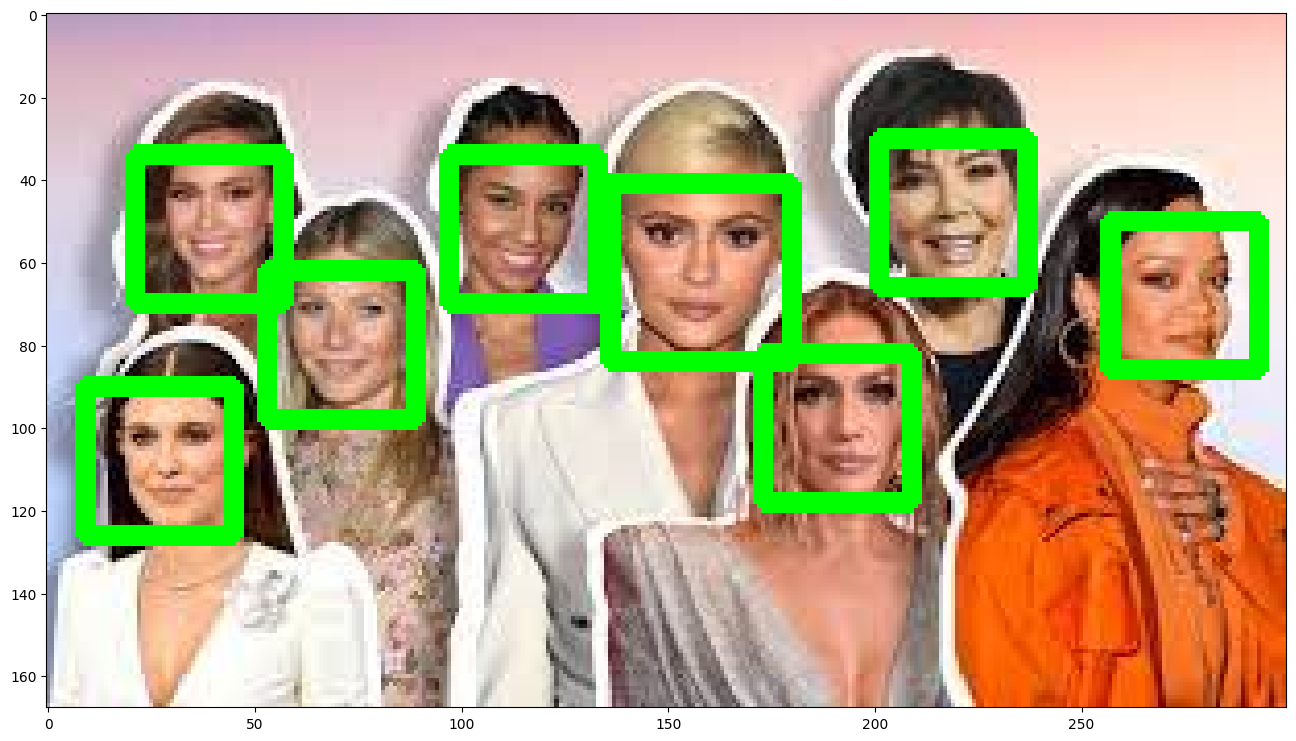

In [ ]:
plt.rcParams['figure.figsize'] = (16,16)
plt.imshow(image)
plt.show()

2. Face Recognition

In [ ]:
plt.rcParams["figure.figsize"] = (1,1)

person_list = []
person_list.append(cv2.imread("/gdrive/MyDrive/Colab Notebooks/haerin.jpg"))
person_list.append(cv2.imread("/gdrive/MyDrive/Colab Notebooks/hanni.jpg"))
person_list.append(cv2.imread("/gdrive/MyDrive/Colab Notebooks/minji01.jpg"))

In [ ]:
face_list = []
for person in person_list:
  top, right, bottom, left = fr.face_locations(person)[0]
  face_image = person[top:bottom, left:right]
  face_list.append(face_image)

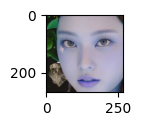

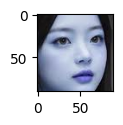

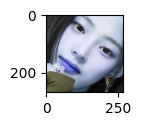

In [ ]:
for face in face_list:
  plt.imshow(face)
  plt.show()

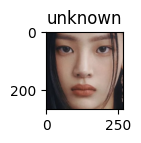

In [ ]:
unknown = fr.load_image_file("/gdrive/MyDrive/Colab Notebooks/minji02.jpg")
top, right, bottom, left = fr.face_locations(unknown)[0]
unknown_face = unknown[top:bottom, left:right]
plt.title('unknown')
plt.imshow(unknown_face)
plt.show()

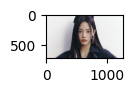

In [ ]:
# unknown_face는 원본 이미지라고 가정하고
unknown_face = cv2.imread('/gdrive/MyDrive/Colab Notebooks/minji02.jpg')

# 원본 이미지를 plt.imshow()로 표시
plt.imshow(cv2.cvtColor(unknown_face, cv2.COLOR_BGR2RGB))
plt.show()


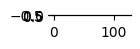

In [ ]:
encoding_unknown = fr.face_encodings(unknown_face)
plt.imshow(encoding_unknown)
plt.show()

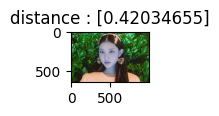

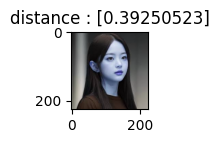

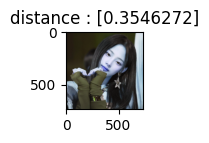

In [ ]:
for face in person_list:
  encoding_known = fr.face_encodings(face)
  distance = fr.face_distance(encoding_known, encoding_unknown[0])
  plt.title("distance : " + str(distance))
  plt.imshow(face)
  plt.show()